# Vehicle Recommendation System - Sauter Digital MVP

## "Others you may like" — Content-Based Recommendation Engine

### The Problem
Sauter Digital's vehicle classifieds platform faces a **user retention problem**: when a customer browses a car (e.g., a 2020 Toyota Corolla), the "Similar Cars" section only shows other 2020 Toyota Corollas. Users abandon the site when they don't find their ideal price or mileage.

### The Solution
We build a **Content-Based Filtering** engine that recommends cars from **competing brands** with similar technical characteristics and prices. This is a **Cold Start** scenario — no user behavior data exists — so we rely exclusively on vehicle attributes from the FIPE dataset.

### Pipeline Overview
1. **Data Loading & EDA** — Understand the dataset structure and distributions
2. **Preprocessing** — Clean, deduplicate, and prepare the data
3. **Feature Engineering** — Encode categoricals, scale numericals
4. **Similarity Engine** — Cosine Similarity for measuring car "closeness"
5. **Business Rules** — Price band filtering, brand exclusion, diversity enforcement
6. **Validation** — Sanity tests, batch checks, edge cases

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

---
## 1. Data Loading and Exploratory Analysis

**Dataset**: FIPE (Fundação Instituto de Pesquisas Econômicas) — Brazilian vehicle price reference table.  
**Source**: Kaggle dataset `vagnerbessa/average-car-prices-bazil`

**Columns:**
| Column | Description |
|--------|-------------|
| `year_of_reference` | Year of the FIPE price reference |
| `month_of_reference` | Month of the FIPE price reference |
| `fipe_code` | Internal FIPE vehicle code |
| `authentication` | Hash for data validation |
| `brand` | Vehicle manufacturer |
| `model` | Vehicle model name |
| `fuel` | Fuel type (Gasoline, Diesel, Alcohol) |
| `gear` | Transmission type (manual, automatic) |
| `engine_size` | Engine displacement in liters |
| `year_model` | Year of the vehicle model |
| `avg_price_brl` | Average price in Brazilian Reais (R$) |
| `age_years` | Age of the vehicle in years |

In [2]:
df = pd.read_csv('fipe_2022.csv')
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
df.head(10)

Shape: (290275, 12)

Data Types:
year_of_reference       int64
month_of_reference     object
fipe_code              object
authentication         object
brand                  object
model                  object
fuel                   object
gear                   object
engine_size           float64
year_model              int64
avg_price_brl         float64
age_years               int64
dtype: object


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,age_years
0,2022,January,038001-6,vwmrywl5qs,Acura,NSX 3.0,Gasoline,manual,3.0,1995,43779.0,28
1,2022,January,038001-6,t9mt723qhz,Acura,NSX 3.0,Gasoline,manual,3.0,1994,42244.0,29
2,2022,January,038001-6,tr5wv4z21g,Acura,NSX 3.0,Gasoline,manual,3.0,1993,40841.0,30
3,2022,January,038001-6,s2xxsjz3mt,Acura,NSX 3.0,Gasoline,manual,3.0,1992,39028.0,31
4,2022,January,038001-6,rtm9gj7zk8,Acura,NSX 3.0,Gasoline,manual,3.0,1991,35678.0,32
5,2022,January,038002-4,nlf2w6k7vd,Acura,Legend 3.2/3.5,Gasoline,manual,3.2,1998,27132.0,25
6,2022,January,038002-4,mcyp7ypwtc,Acura,Legend 3.2/3.5,Gasoline,manual,3.2,1997,23934.0,26
7,2022,January,038002-4,lxckds9y6h,Acura,Legend 3.2/3.5,Gasoline,manual,3.2,1996,22690.0,27
8,2022,January,038002-4,k1fntq7ycs,Acura,Legend 3.2/3.5,Gasoline,manual,3.2,1995,20393.0,28
9,2022,January,038002-4,j1b3jg70bz,Acura,Legend 3.2/3.5,Gasoline,manual,3.2,1994,17742.0,29


In [3]:
print(f"Unique brands: {df['brand'].nunique()}")
print(f"Unique models: {df['model'].nunique()}")
print(f"Fuel types: {list(df['fuel'].unique())}")
print(f"Gear types: {list(df['gear'].unique())}")
print(f"Engine size range: {df['engine_size'].min()} - {df['engine_size'].max()}")
print(f"Price range: R${df['avg_price_brl'].min():,.0f} - R${df['avg_price_brl'].max():,.0f}")
print(f"Year model range: {df['year_model'].min()} - {df['year_model'].max()}")
print(f"Age range: {df['age_years'].min()} - {df['age_years'].max()} years")
print(f"\nNull values:\n{df.isnull().sum()}")

Unique brands: 86
Unique models: 6064
Fuel types: ['Gasoline', 'Diesel', 'Alcohol']
Gear types: ['manual', 'automatic']
Engine size range: 0.7 - 6.7
Price range: R$1,831 - R$8,600,000
Year model range: 1985 - 2023
Age range: 0 - 38 years

Null values:
year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
brand                 0
model                 0
fuel                  0
gear                  0
engine_size           0
year_model            0
avg_price_brl         0
age_years             0
dtype: int64


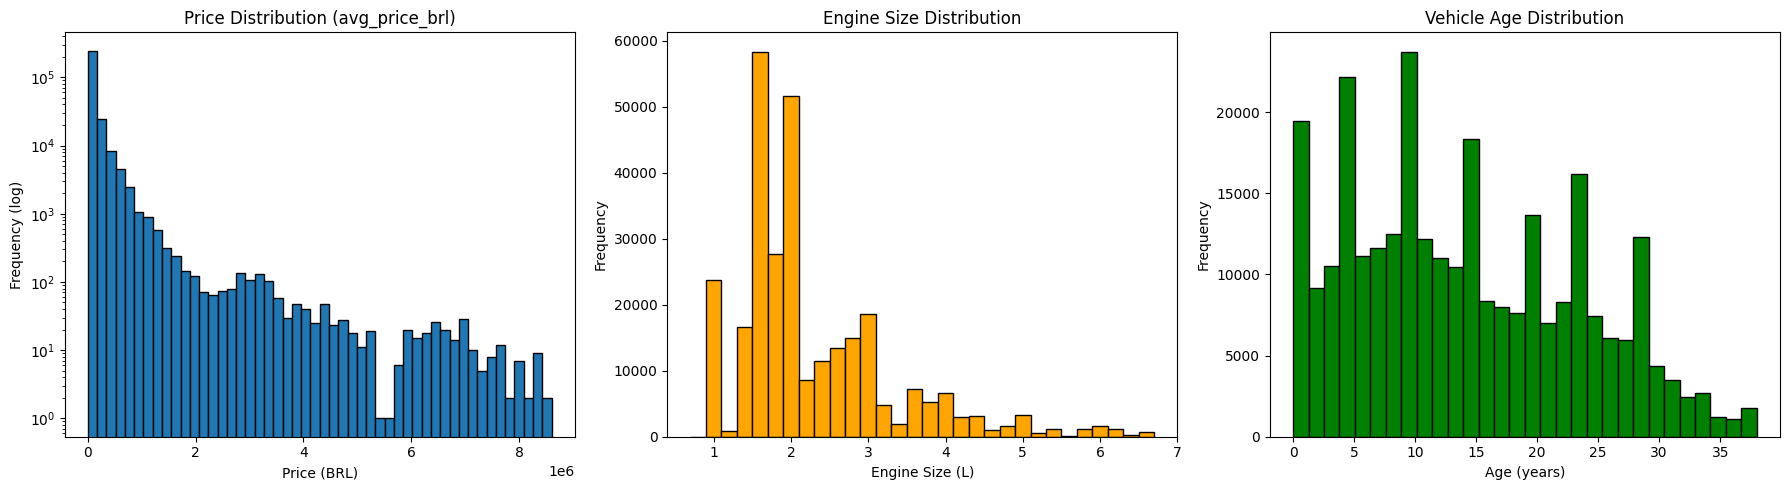

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['avg_price_brl'], bins=50, edgecolor='black')
axes[0].set_title('Price Distribution (avg_price_brl)')
axes[0].set_xlabel('Price (BRL)')
axes[0].set_yscale('log')
axes[0].set_ylabel('Frequency (log)')

axes[1].hist(df['engine_size'], bins=30, edgecolor='black', color='orange')
axes[1].set_title('Engine Size Distribution')
axes[1].set_xlabel('Engine Size (L)')
axes[1].set_ylabel('Frequency')

axes[2].hist(df['age_years'], bins=30, edgecolor='black', color='green')
axes[2].set_title('Vehicle Age Distribution')
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [5]:
# Monthly duplication analysis — same car appears ~12 times (once per month)
duplication = df.groupby(['fipe_code', 'year_model']).size()
print(f"Entries per fipe_code + year_model combination:\n{duplication.describe()}")
print(f"\nThis confirms ~12 monthly entries per car configuration → needs deduplication")

Entries per fipe_code + year_model combination:
count    24033.000000
mean        12.078184
std          1.939134
min          1.000000
25%         12.000000
50%         12.000000
75%         12.000000
max         24.000000
dtype: float64

This confirms ~12 monthly entries per car configuration → needs deduplication


---
## 2. Feature Selection — Data Cleaning and Deduplication

### Columns to Drop
We discard columns that carry **no predictive value** for vehicle similarity:

| Column | Reason for Removal |
|--------|--------------------|
| `year_of_reference` | All values are 2022 — constant, no discriminative information |
| `month_of_reference` | FIPE reference period — administrative metadata, not a vehicle attribute |
| `fipe_code` | Internal FIPE identifier — not a characteristic of the vehicle itself |
| `authentication` | Random validation hash — no semantic meaning |

### Deduplication Strategy
Each unique car configuration (`brand` + `model` + `fuel` + `gear` + `engine_size` + `year_model`) appears **~12 times** in the dataset (one entry per month). We collapse these into a single row by **averaging the monthly prices** — this gives us the 2022 annual average price and eliminates temporal noise.

In [6]:
# Drop administrative columns
cols_to_drop = ['year_of_reference', 'month_of_reference', 'fipe_code', 'authentication']
df_clean = df.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {list(df_clean.columns)}")
print(f"Shape after drop: {df_clean.shape}")

Dropped columns: ['year_of_reference', 'month_of_reference', 'fipe_code', 'authentication']
Remaining columns: ['brand', 'model', 'fuel', 'gear', 'engine_size', 'year_model', 'avg_price_brl', 'age_years']
Shape after drop: (290275, 8)


In [7]:
# Deduplicate: group by unique car configuration, average monthly prices
group_cols = ['brand', 'model', 'fuel', 'gear', 'engine_size', 'year_model']
df_dedup = df_clean.groupby(group_cols, as_index=False).agg({
    'avg_price_brl': 'mean',
    'age_years': 'first'  # constant for same year_model
})

print(f"Before dedup: {df_clean.shape[0]:,} rows")
print(f"After dedup:  {df_dedup.shape[0]:,} rows")
print(f"Reduction:    {(1 - df_dedup.shape[0]/df_clean.shape[0])*100:.1f}%")

Before dedup: 290,275 rows
After dedup:  24,932 rows
Reduction:    91.4%


In [8]:
# Spot-check: verify deduplication on a known model
corolla = df_dedup[df_dedup['model'].str.contains('Corolla', case=False)]
print(f"Corolla variants after dedup: {len(corolla)}")
corolla.sort_values('year_model', ascending=False).head(10)

Corolla variants after dedup: 216


,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,age_years
21016,Toyota,Corolla Altis 1.8 16V Aut. (Híbrido),Gasoline,automatic,1.8,2023,177968.000000,0
21020,Toyota,Corolla Altis Hybrid 1.8 16V Aut.,Gasoline,automatic,1.8,2023,175179.500000,0
21012,Toyota,Corolla ALTIS/A.Premiu. 2.0 Flex 16V Aut,Gasoline,automatic,2.0,2023,173595.217391,0
21037,Toyota,Corolla Cross GR-S 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,184451.375000,0
21032,Toyota,Corolla Altis Prem. Hybrid 1.8 Aut,Gasoline,automatic,1.8,2023,182210.000000,0
21036,Toyota,Corolla Altis Prem. Hybrid 1.8 Flex Aut,Gasoline,automatic,1.8,2023,182216.461538,0
21028,Toyota,Corolla Altis Prem. 1.8 Aut. (Híbrido),Gasoline,automatic,1.8,2023,184637.375000,0
21024,Toyota,Corolla Altis Hybrid 1.8 16V Flex Aut.,Gasoline,automatic,1.8,2023,175819.230769,0
21040,Toyota,Corolla Cross SE 1.8 16V Aut. (Híbrido),Gasoline,automatic,1.8,2023,211221.571429,0
21042,Toyota,Corolla Cross XR 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,158098.565217,0


---
## 3. Feature Engineering — Encoding and Scaling

### Why `StandardScaler` (not `MinMaxScaler`)?
The price distribution is **heavily right-skewed** — values range from R\$1,831 to R\$8,600,000. `MinMaxScaler` would compress 99% of mass-market cars into a tiny range near 0, destroying the algorithm's ability to distinguish a R\$40K car from a R\$80K one. `StandardScaler` centers features on mean with unit variance, preserving discriminative power across all price segments.

### Why `One-Hot Encoding` with `drop_first=False`?
`fuel` (3 categories) and `gear` (2 categories) are **nominal** variables — no ordinal relationship exists. We use `drop_first=False` because Cosine Similarity benefits from **full representation**: dropping a reference category creates an asymmetry where one fuel type has no explicit signal in the feature vector.

### Why drop `year_model`?
`age_years` and `year_model` are **linearly dependent** (`age = 2023 - year_model`). Keeping both would double-weight the age dimension in the similarity calculation.

### Final Feature Vector (8 dimensions)
| # | Feature | Type | Scaling |
|---|---------|------|---------|
| 1 | `engine_size` | Numerical | StandardScaler |
| 2 | `avg_price_brl` | Numerical | StandardScaler |
| 3 | `age_years` | Numerical | StandardScaler |
| 4 | `fuel_Gasoline` | Binary | None needed |
| 5 | `fuel_Diesel` | Binary | None needed |
| 6 | `fuel_Alcohol` | Binary | None needed |
| 7 | `gear_manual` | Binary | None needed |
| 8 | `gear_automatic` | Binary | None needed |

In [9]:
# Separate label columns (for display in results, not used in similarity computation)
labels = df_dedup[['brand', 'model']].reset_index(drop=True)

# Build feature dataframe: drop brand, model, year_model (redundant with age_years)
df_features = df_dedup.drop(columns=['brand', 'model', 'year_model'])

# One-Hot Encode categorical variables
df_features = pd.get_dummies(df_features, columns=['fuel', 'gear'], drop_first=False)

print(f"Feature columns: {list(df_features.columns)}")
print(f"Feature matrix shape: {df_features.shape}")

Feature columns: ['engine_size', 'avg_price_brl', 'age_years', 'fuel_Alcohol', 'fuel_Diesel', 'fuel_Gasoline', 'gear_automatic', 'gear_manual']
Feature matrix shape: (24932, 8)


In [10]:
# Scale numerical features with StandardScaler
numerical_cols = ['engine_size', 'avg_price_brl', 'age_years']
scaler = StandardScaler()
df_features[numerical_cols] = scaler.fit_transform(df_features[numerical_cols])

print("Scaled feature statistics (mean ≈ 0, std ≈ 1 for numerical columns):")
df_features.describe().round(2)

Scaled feature statistics (mean ≈ 0, std ≈ 1 for numerical columns):


,engine_size,avg_price_brl,age_years
count,24932.00,24932.00,24932.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.53,-0.39,-1.47
25%,-0.65,-0.33,-0.83
50%,-0.26,-0.25,-0.19
75%,0.51,-0.05,0.77
max,4.30,25.28,2.59


In [11]:
# Convert to numpy matrix for similarity computation
feature_matrix = df_features.values

# Reset df_dedup index to align with labels and feature_matrix
df_dedup = df_dedup.reset_index(drop=True)

print(f"Final feature matrix: {feature_matrix.shape}")
print(f"Features: {list(df_features.columns)}")

Final feature matrix: (24932, 8)
Features: ['engine_size', 'avg_price_brl', 'age_years', 'fuel_Alcohol', 'fuel_Diesel', 'fuel_Gasoline', 'gear_automatic', 'gear_manual']


---
## 4. The Mathematical Engine — Cosine Similarity

### Why Cosine Similarity over Euclidean Distance?
- **Cosine** measures the **angle** between feature vectors — it captures how similar the *profile shape* of two cars is, regardless of absolute magnitude differences.
- **Euclidean** measures absolute distance — even after scaling, it can be dominated by one feature dimension and produces unbounded values that are harder to interpret.
- Cosine produces values in **[0, 1]** (for non-negative features), making scores intuitive: `1.0` = identical profile, `0.0` = completely different.

### Memory-Efficient Approach
The full similarity matrix for ~24K cars would be **24K × 24K ≈ 4.6 GB** — too large for most machines. Instead, we compute similarity **on-the-fly** for a single query car (a 24K-element vector) in milliseconds.

In [12]:
def compute_similarities(query_idx, feature_matrix):
    """Compute cosine similarity between a query car and all others."""
    query_vector = feature_matrix[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_vector, feature_matrix)[0]
    return similarities

# Quick sanity test
test_sim = compute_similarities(0, feature_matrix)
print(f"Similarity vector shape: {test_sim.shape}")
print(f"Self-similarity (should be 1.0): {test_sim[0]:.4f}")
print(f"Min similarity: {test_sim.min():.4f}")
print(f"Max similarity (excluding self): {np.sort(test_sim)[-2]:.4f}")

Similarity vector shape: (24932,)
Self-similarity (should be 1.0): 1.0000
Min similarity: -0.6633
Max similarity (excluding self): 0.9999


---
## 5. Business Rules and Recommendation Function

### Business Rules Implemented

1. **Price Band Filter (±25%)**: A R\$50,000 car must never be recommended to someone browsing a R\$300,000 car. We enforce a **±25% price tolerance** around the query car's original (unscaled) price, filtering candidates *before* similarity computation.

2. **Brand Exclusion**: The Product team's core requirement — the carousel must show **only competing brands**. All cars from the same brand as the query are excluded from results.

3. **Brand Diversity Cap**: To prevent the carousel from showing 5 cars from the same competitor, we enforce a **maximum of 2 recommendations per brand**, ensuring the user sees variety across manufacturers.

In [13]:
def recommend(brand, model, year_model=None, top_n=5, price_tolerance=0.25, max_per_brand=2):
    """
    Recommend similar cars from competing brands.

    Parameters
    ----------
    brand : str
        Brand of the query car (e.g., "Toyota").
    model : str
        Model name — supports partial match (e.g., "Corolla").
    year_model : int, optional
        Specific year; if None, uses the most recent available.
    top_n : int
        Number of recommendations to return (default: 5).
    price_tolerance : float
        Price band as a fraction (0.25 = ±25% of query car price).
    max_per_brand : int
        Maximum recommendations per competing brand (ensures diversity).

    Returns
    -------
    pd.DataFrame with recommended cars and similarity scores.
    """

    # 1. Lookup the query car
    mask = (labels['brand'].str.lower() == brand.lower()) & \
           (labels['model'].str.contains(model, case=False, na=False))

    if year_model is not None:
        mask = mask & (df_dedup['year_model'] == year_model)

    candidates_idx = df_dedup[mask].index.tolist()

    if not candidates_idx:
        print(f"Car not found: {brand} {model} {year_model or ''}")
        return pd.DataFrame()

    # Pick the most recent year_model if not specified
    if year_model is None:
        query_idx = df_dedup.loc[candidates_idx, 'year_model'].idxmax()
    else:
        query_idx = candidates_idx[0]

    query_car = df_dedup.loc[query_idx]
    query_price = query_car['avg_price_brl']
    query_brand = query_car['brand']

    print(f"Query: {query_car['brand']} {query_car['model']} ({int(query_car['year_model'])})")
    print(f"Price: R${query_price:,.0f} | Engine: {query_car['engine_size']}L | "
          f"Fuel: {query_car['fuel']} | Gear: {query_car['gear']}")
    print(f"Price band: R${query_price*(1-price_tolerance):,.0f} — R${query_price*(1+price_tolerance):,.0f}")
    print("-" * 70)

    # 2. Price band filter (applied on original unscaled prices)
    price_min = query_price * (1 - price_tolerance)
    price_max = query_price * (1 + price_tolerance)
    price_mask = (df_dedup['avg_price_brl'] >= price_min) & (df_dedup['avg_price_brl'] <= price_max)

    # 3. Brand exclusion filter
    brand_mask = labels['brand'] != query_brand

    # Combined filter
    valid_mask = price_mask & brand_mask
    valid_indices = df_dedup[valid_mask].index.tolist()

    if not valid_indices:
        print("No candidates found within price band from other brands.")
        return pd.DataFrame()

    # 4. Compute cosine similarity only against valid candidates
    query_vector = feature_matrix[query_idx].reshape(1, -1)
    candidate_vectors = feature_matrix[valid_indices]
    similarities = cosine_similarity(query_vector, candidate_vectors)[0]

    # 5. Sort by similarity (descending)
    sim_order = np.argsort(similarities)[::-1]

    # 6. Brand diversity enforcement
    results = []
    brand_counts = {}
    for idx in sim_order:
        actual_idx = valid_indices[idx]
        car = df_dedup.loc[actual_idx]
        car_brand = labels.loc[actual_idx, 'brand']

        if brand_counts.get(car_brand, 0) >= max_per_brand:
            continue

        brand_counts[car_brand] = brand_counts.get(car_brand, 0) + 1
        results.append({
            'brand': car_brand,
            'model': labels.loc[actual_idx, 'model'],
            'fuel': car['fuel'],
            'gear': car['gear'],
            'engine_size': car['engine_size'],
            'year_model': int(car['year_model']),
            'avg_price_brl': round(car['avg_price_brl'], 2),
            'similarity_score': round(similarities[idx], 4)
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)


def display_recommendations(results_df):
    """Format recommendation results for display."""
    if results_df.empty:
        print("No recommendations available.")
        return results_df

    display_df = results_df.copy()
    display_df['avg_price_brl'] = display_df['avg_price_brl'].apply(lambda x: f"R${x:,.0f}")
    display_df['similarity_score'] = display_df['similarity_score'].apply(lambda x: f"{x:.2%}")
    display_df.index = range(1, len(display_df) + 1)
    display_df.index.name = 'Rank'
    return display_df

---
## 6. Validation Strategy

Since there are **no real users** to evaluate click-through rates, we validate the system using three complementary approaches:

1. **Sanity Test Cases**: Run queries for well-known cars and verify that results match expected market competitors (e.g., Toyota Corolla → Honda Civic, Nissan Sentra)
2. **Price Coherence Check**: Batch-test 100 random cars and confirm ALL results fall within the ±25% price band
3. **Brand Diversity Check**: Verify that no result shares the query car's brand and no single brand exceeds the diversity cap
4. **Edge Cases**: Test with extreme prices (Ferrari), old cars (1985), and rare brands

### 6.1 Sanity Test Cases — Known Market Competitors

In [14]:
print("=" * 70)
print("TEST 1: Toyota Corolla (popular sedan)")
print("Expected competitors: Honda Civic, Nissan Sentra, VW Jetta")
print("=" * 70)
results_corolla = recommend("Toyota", "Corolla")
display_recommendations(results_corolla)

TEST 1: Toyota Corolla (popular sedan)
Expected competitors: Honda Civic, Nissan Sentra, VW Jetta
Query: Toyota Corolla ALTIS/A.Premiu. 2.0 Flex 16V Aut (2023)
Price: R$173,595 | Engine: 2.0L | Fuel: Gasoline | Gear: automatic
Price band: R$130,196 — R$216,994
----------------------------------------------------------------------


,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,similarity_score
Rank,,,,,,,,
1,Mitsubishi,OUTLANDER Sport HPE 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,"R$174,881",100.00%
2,Jeep,COMPASS LIMITED 2.0 4x2 Flex 16V Aut.,Gasoline,automatic,2.0,2023,"R$175,905",100.00%
3,Mitsubishi,OUTLANDER SP. HPE BL.ED 4x2 2.0 Flex Aut,Gasoline,automatic,2.0,2023,"R$178,237",100.00%
4,Hyundai,Creta Ultimate 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,"R$166,312",99.99%
5,Subaru,XV 2.0/2.0 S/2.0 ES 16V 4x4 Aut.,Gasoline,automatic,2.0,2023,"R$183,414",99.99%


In [15]:
print("=" * 70)
print("TEST 2: VW Gol (economy hatch)")
print("Expected competitors: Fiat Uno/Mobi, Chevrolet Onix, Hyundai HB20")
print("=" * 70)
results_gol = recommend("VW - Volkswagen", "Gol")
display_recommendations(results_gol)

TEST 2: VW Gol (economy hatch)
Expected competitors: Fiat Uno/Mobi, Chevrolet Onix, Hyundai HB20
Query: VW - VolksWagen Gol 1.0 Flex 12V 5p (2023)
Price: R$71,977 | Engine: 1.0L | Fuel: Gasoline | Gear: manual
Price band: R$53,983 — R$89,972
----------------------------------------------------------------------


,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,similarity_score
Rank,,,,,,,,
1,Fiat,UNO ATTRACTIVE 1.0 Fire Flex 8V 5p,Gasoline,manual,1.0,2023,"R$71,292",100.00%
2,Citroën,C3 Live Pack 1.0 Flex 6V 5p Mec.,Gasoline,manual,1.0,2023,"R$73,466",100.00%
3,Renault,SANDERO Zen Flex 1.0 12V 5p Mec.,Gasoline,manual,1.0,2023,"R$73,879",100.00%
4,Fiat,CRONOS 1.0 6V Flex,Gasoline,manual,1.0,2023,"R$74,822",100.00%
5,Renault,SANDERO Life Flex 1.0 12V 5p Mec.,Gasoline,manual,1.0,2023,"R$69,086",100.00%


In [16]:
print("=" * 70)
print("TEST 3: BMW 320i (luxury sedan)")
print("Expected competitors: Mercedes C-Class, Audi A4, Volvo S60")
print("=" * 70)
results_bmw = recommend("BMW", "320i")
display_recommendations(results_bmw)

TEST 3: BMW 320i (luxury sedan)
Expected competitors: Mercedes C-Class, Audi A4, Volvo S60
Query: BMW 320iA 2.0 TB M Sport A.Flex/M.Sport 4p (2023)
Price: R$334,293 | Engine: 2.0L | Fuel: Gasoline | Gear: manual
Price band: R$250,719 — R$417,866
----------------------------------------------------------------------


,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,similarity_score
Rank,,,,,,,,
1,Mercedes-Benz,A 250 2.0 TB Hatch,Gasoline,manual,2.0,2023,"R$339,582",100.00%
2,Audi,A5 Sportb.Prestige Plus 2.0 TFSI S-tronc,Gasoline,manual,2.0,2023,"R$340,514",100.00%
3,Volvo,XC 60 T-5 MOMENTUM 2.0 254cv AWD 5p,Gasoline,manual,2.0,2023,"R$326,981",100.00%
4,Audi,Q3 Perf. Black 2.0 TFSI Tiptr. Quattro,Gasoline,manual,2.0,2023,"R$324,980",99.99%
5,Volvo,S60 T-8 R-DESIGN 2.0 407cv (Híbrido),Gasoline,manual,2.0,2023,"R$347,218",99.98%


### 6.2 Automated Batch Validation — Price Coherence & Brand Diversity

In [17]:
# Batch validation: test 100 random cars for price coherence and brand diversity
np.random.seed(42)
sample_indices = np.random.choice(len(df_dedup), size=100, replace=False)

price_violations = 0
same_brand_count = 0
brand_cap_violations = 0
successful_queries = 0

import io, sys

for idx in sample_indices:
    car = df_dedup.iloc[idx]

    # Suppress print output during batch test
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()

    results = recommend(
        labels.iloc[idx]['brand'],
        labels.iloc[idx]['model'],
        year_model=int(car['year_model']),
        top_n=5
    )

    sys.stdout = old_stdout

    if results.empty:
        continue

    successful_queries += 1
    price = car['avg_price_brl']

    # Price coherence check
    price_min = price * 0.75
    price_max = price * 1.25
    out_of_band = results[
        (results['avg_price_brl'] < price_min) | (results['avg_price_brl'] > price_max)
    ]
    price_violations += len(out_of_band)

    # Brand exclusion check
    same = results[results['brand'] == labels.iloc[idx]['brand']]
    same_brand_count += len(same)

    # Brand diversity cap check
    for b, count in results['brand'].value_counts().items():
        if count > 2:
            brand_cap_violations += 1

print(f"Batch Validation Results ({successful_queries}/100 queries returned results)")
print(f"{'='*50}")
print(f"Price band violations:        {price_violations} (should be 0)")
print(f"Same-brand recommendations:   {same_brand_count} (should be 0)")
print(f"Brand cap violations (>2):    {brand_cap_violations} (should be 0)")
print(f"\nAll checks passed!" if (price_violations + same_brand_count + brand_cap_violations) == 0 else "\nSome checks failed — review above.")

Batch Validation Results (96/100 queries returned results)
Price band violations:        0 (should be 0)
Same-brand recommendations:   0 (should be 0)
Brand cap violations (>2):    0 (should be 0)

All checks passed!


### 6.3 Edge Cases

In [18]:
print("=" * 70)
print("EDGE CASE 1: Luxury/Expensive car (Porsche)")
print("=" * 70)
results_porsche = recommend("Porsche", "911", top_n=3)
display_recommendations(results_porsche)

EDGE CASE 1: Luxury/Expensive car (Porsche)
Query: Porsche 911 4 GTS Targa 3.0 24V (991) (2023)
Price: R$1,261,250 | Engine: 3.0L | Fuel: Gasoline | Gear: manual
Price band: R$945,938 — R$1,576,562
----------------------------------------------------------------------


,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,similarity_score
Rank,,,,,,,,
1,Mercedes-Benz,E-63 S AMG 4MATIC 4.0 V8 612cv,Gasoline,manual,4.0,2023,"R$1,445,462",98.16%
2,Mercedes-Benz,E-63 S AMG 4MATIC 4.0 V8 612cv,Gasoline,manual,4.0,2021,"R$1,342,168",97.58%
3,Audi,RS Q8 4.0 Bi-TB V8 FSI Quattro Tiptronic,Gasoline,manual,4.0,2023,"R$1,259,511",97.54%


In [19]:
print("=" * 70)
print("EDGE CASE 2: Honda Civic (another popular sedan for cross-validation)")
print("=" * 70)
results_civic = recommend("Honda", "Civic")
display_recommendations(results_civic)

EDGE CASE 2: Honda Civic (another popular sedan for cross-validation)
Query: Honda Civic Sedan EX 2.0 Flex 16V Aut.4p (2023)
Price: R$137,789 | Engine: 2.0L | Fuel: Gasoline | Gear: automatic
Price band: R$103,342 — R$172,236
----------------------------------------------------------------------


,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,similarity_score
Rank,,,,,,,,
1,Toyota,Corolla GLi 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,"R$141,492",100.00%
2,LIFAN,X80 VIP 2.0 Turbo 184cv 5p Aut.,Gasoline,automatic,2.0,2023,"R$143,020",100.00%
3,Jeep,COMPASS SPORT 2.0 4x2 Flex 16V Aut.,Gasoline,automatic,2.0,2023,"R$143,055",100.00%
4,Kia Motors,Cerato EX 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,"R$130,644",99.99%
5,Kia Motors,Cerato SX 2.0 16V Flex Aut.,Gasoline,automatic,2.0,2023,"R$146,716",99.99%


---
## 7. Results Visualization — "Others you may like" Carousel Preview

Query: Toyota Corolla ALTIS/A.Premiu. 2.0 Flex 16V Aut (2023)
Price: R$173,595 | Engine: 2.0L | Fuel: Gasoline | Gear: automatic
Price band: R$130,196 — R$216,994
----------------------------------------------------------------------


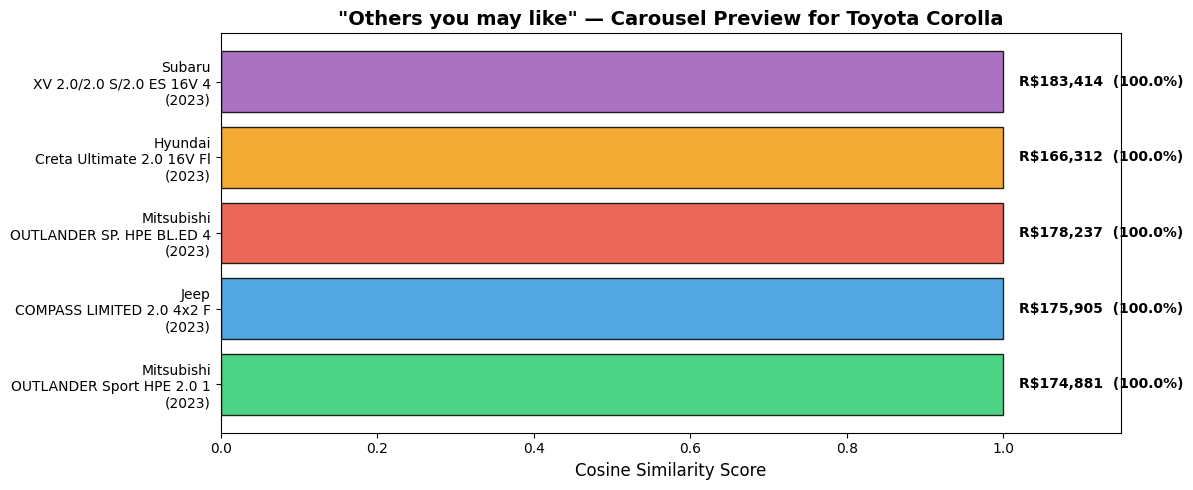

In [20]:
# Visualization: Carousel preview for Toyota Corolla recommendations
results = recommend("Toyota", "Corolla", top_n=5)

if not results.empty:
    fig, ax = plt.subplots(figsize=(12, 5))

    car_labels = [f"{r['brand']}\n{r['model'][:25]}\n({r['year_model']})"
                  for _, r in results.iterrows()]
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'][:len(results)]

    bars = ax.barh(car_labels, results['similarity_score'], color=colors, edgecolor='black', alpha=0.85)
    ax.set_xlabel('Cosine Similarity Score', fontsize=12)
    ax.set_title('"Others you may like" — Carousel Preview for Toyota Corolla', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.15)

    for bar, (_, row) in zip(bars, results.iterrows()):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"R${row['avg_price_brl']:,.0f}  ({row['similarity_score']:.1%})",
                va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

Query: VW - VolksWagen Gol 1.0 Flex 12V 5p (2023)
Price: R$71,977 | Engine: 1.0L | Fuel: Gasoline | Gear: manual
Price band: R$53,983 — R$89,972
----------------------------------------------------------------------


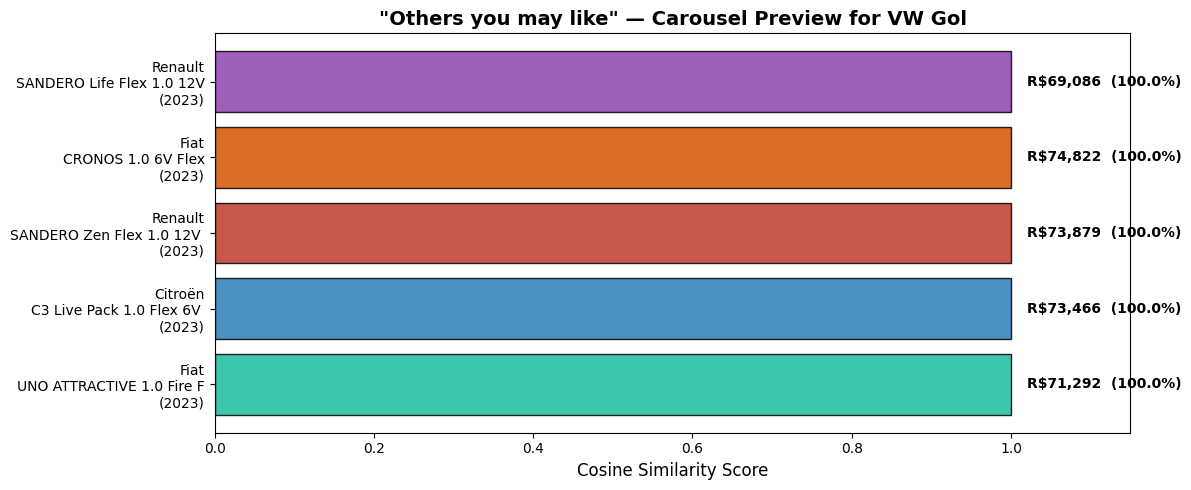

In [21]:
# Visualization: Carousel preview for VW Gol recommendations
results_gol_vis = recommend("VW - Volkswagen", "Gol", top_n=5)

if not results_gol_vis.empty:
    fig, ax = plt.subplots(figsize=(12, 5))

    car_labels = [f"{r['brand']}\n{r['model'][:25]}\n({r['year_model']})"
                  for _, r in results_gol_vis.iterrows()]
    colors = ['#1abc9c', '#2980b9', '#c0392b', '#d35400', '#8e44ad'][:len(results_gol_vis)]

    bars = ax.barh(car_labels, results_gol_vis['similarity_score'], color=colors, edgecolor='black', alpha=0.85)
    ax.set_xlabel('Cosine Similarity Score', fontsize=12)
    ax.set_title('"Others you may like" — Carousel Preview for VW Gol', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.15)

    for bar, (_, row) in zip(bars, results_gol_vis.iterrows()):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"R${row['avg_price_brl']:,.0f}  ({row['similarity_score']:.1%})",
                va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()